In [2]:
from matplotlib import pyplot as plt
from math import log2
import numpy as np
import matplotlib as mpl


In [16]:
data = np.array([
[30, 2.0],
[60, 2.0],
[60, 2.0],
[30, 0.0],
[30, 2.0],
[30, 0.0],
[60, 2.0],
[30, 2.0],
[60, 0.0],
[60, 2.0],
])
data = np.array(sorted(data, key=lambda e: e[0]))
np.save('../../out/edge/data.gurobi.k501', data)

In [18]:
dwave_data_k71 = np.load('../../out/edge/data.dwave.k71.npy')
dwave_data_k101 = np.load('../../out/edge/data.dwave.k101.npy')
dwave_data_k201 = np.load('../../out/edge/data.dwave.k201.npy')
dwave_data_k301 = np.load('../../out/edge/data.dwave.k301.npy')
dwave_data_k501 = np.load('../../out/edge/data.dwave.k501.npy')


mqlib_data_k61 = np.load('../../out/edge/data.mqlib.k61.npy')
mqlib_data_k71 = np.load('../../out/edge/data.mqlib.k71.npy')
mqlib_data_k201 = np.load('../../out/edge/data.mqlib.k201.npy')
mqlib_data_k301 = np.load('../../out/edge/data.mqlib.k301.npy')
mqlib_data_k501 = np.load('../../out/edge/data.mqlib.k501.npy')


gurobi_data_k71 = np.load('../../out/edge/data.gurobi.k71.npy')
gurobi_data_k201 = np.load('../../out/edge/data.gurobi.k201.npy')
gurobi_data_k301 = np.load('../../out/edge/data.gurobi.k301.npy')
gurobi_data_k501 = np.load('../../out/edge/data.gurobi.k501.npy')

In [6]:
times, counts = np.unique(mqlib_data_k61[:,0], return_counts=True)
print(times, counts)

[ 60 120 240 480 960] [5 5 5 5 5]


In [19]:
data, counts = np.unique(mqlib_data_k71, return_counts=True)
print(data, counts)

[  0   2   3   4  30  60 120 240] [10  4  4  2  5  5  5  5]


In [28]:
def compare_solvers(*args):
    fig, ax = plt.subplots()
    
    cmap = mpl.colormaps['magma_r']
    
    colours = cmap(np.linspace(0.1, 0.9, len(args)))
    names = ['D-Wave', 'Gurobi', 'MQLib']
    markers = ['o', 'x', 's', 'v']
    
    for idx, data in enumerate(args):
        unique_data, unique_counts = np.unique(data, return_counts=True, axis=0)
        # times, time_counts = np.unique(data[:, 0], return_counts=True)
        marker_sizes = np.zeros_like(unique_data[:, 0])
        for i in range(unique_counts.shape[0]):
            # marker_sizes[i] = 10 ** 2 * (unique_counts[i] / time_counts[np.argmax(times == unique_data[i, 0])])
            marker_sizes[i] = 5 ** 2 * (unique_counts[i])
        ax.scatter(unique_data[:, 0] / 60, unique_data[:, 1], s=marker_sizes, color=colours[idx], label=names[idx], alpha=0.5, marker=markers[idx])
        
    ax.set_xlabel(r'$T / 60$')
    ax.set_ylabel(r'Energy')
    ax.set_xscale('log', base=2)
    # ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))
    ax.grid(True, which="both")
    fig.tight_layout()
    plt.show()

In [21]:
def compare_problem_sizes(*args):
    fig, ax = plt.subplots()
    
    cmap = mpl.colormaps['magma_r']

    # Take colors at regular intervals spanning the colormap.
    colours = cmap(np.linspace(0.1, 0.9, len(args)))
    
    markers = ['o', 'x', 's', 'v']
    
    kmer_sizes = [arg[0] for arg in args]
    
    for idx, data in enumerate(args):
        unique_data, unique_counts = np.unique(data[1], return_counts=True, axis=0)
        # times, time_counts = np.unique(data[:, 0], return_counts=True)
        marker_sizes = np.zeros_like(unique_data[:, 0])
        for i in range(unique_counts.shape[0]):
            # marker_sizes[i] = 10 ** 2 * (unique_counts[i] / time_counts[np.argmax(times == unique_data[i, 0])])
            marker_sizes[i] = 5 ** 2 * (unique_counts[i])
        ax.scatter(
            np.round(unique_data[:, 0] / 60, 1), unique_data[:, 1], 
            s=marker_sizes, color=colours[idx], label=kmer_sizes[idx], alpha=0.5, marker=markers[idx]
        )
    
    ax.set_xlabel(r'$T / 60$')
    ax.set_ylabel(r'Energy')
    ax.set_xscale('log', base=2)
    # ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), title='k')
    ax.grid(True, which="both")
    fig.tight_layout()
    plt.show()

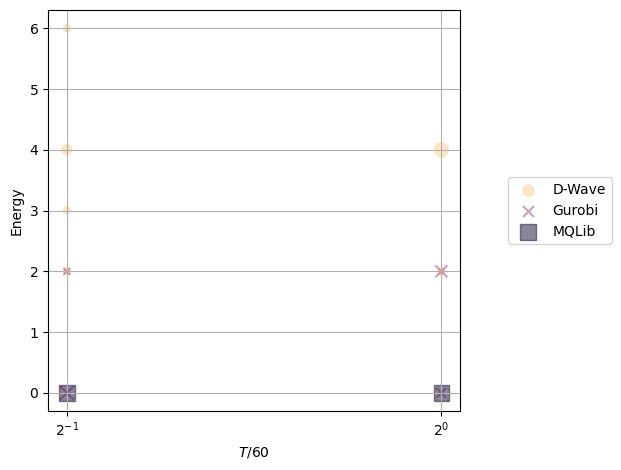

In [29]:
compare_solvers(dwave_data_k201, gurobi_data_k201, mqlib_data_k201)

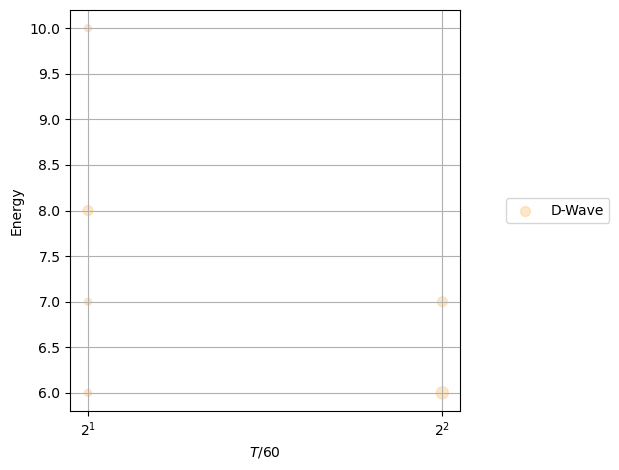

In [30]:
compare_solvers(dwave_data_k101)

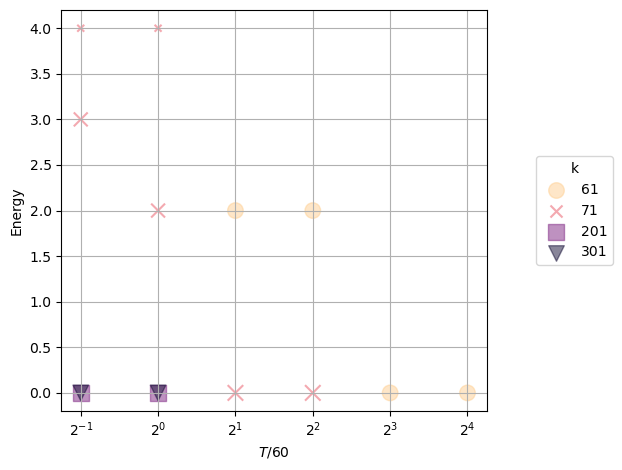

In [27]:
compare_problem_sizes(
    (61, mqlib_data_k61), 
    (71, mqlib_data_k71), 
    (201, mqlib_data_k201),
    (301, mqlib_data_k201),
)

In [97]:
2 ** 1.5 * 60

169.7056274847714